# Genus-1 loop DOF: how the cohomology cut is selected

The scalar-potential BIE + SIBC workpiece solver
(`radia.bem_sibc_solver`) uses a single-valued magnetic scalar
potential $\varphi$ on the workpiece surface $\Gamma$.  On a **genus-1**
workpiece (ring / tube) whose bore links the coil flux, the physical
eddy current has a *net circulating* (toroidal) component --- the
shorted transformer turn --- that a single-valued $\varphi$ **cannot
represent** ($\mathbf{J}_s=\mathbf{n}\times(-\nabla_s\varphi)$ carries
zero net current across any surface cut).

`radia.bem_loop_extension` restores it with **one** extra scalar DOF
$\alpha$ (the net toroidal current):
$\varphi_\mathrm{multi}=\varphi_u+\alpha\,\Theta$.  This notebook shows,
on a real unstructured genus-1 mesh, **how the cut loop for $\Theta$ is
selected automatically** --- and why a naive fixed generator basis is
not enough (it can come out *class-mixed*, exactly as measured on the
paper's Takahashi stepped-tube workpiece).

## The selection, in three steps

**(1) How many DOFs.**  From the Euler characteristic
$\chi=n_v-n_e+n_t$, $\;\mathrm{genus}=(2-\chi)/2$.  One $\alpha$ per
flux-linked handle; genus-1 $\Rightarrow$ one cut, one $\alpha$
(genus 0 needs none; genus $\ge 2$ raises).

**(2) Which loop is the cut.**  Not a fixed combinatorial dual-tree
basis --- that can be *class-mixed*.  Instead:

* build the **harmonic 1-cochain** basis on $\Gamma$ and form the
  **period matrix** $\Pi$ (periods over every cotree fundamental cycle);
* the class map $H_1\to\mathbb{R}^{b_1}$ is **linear**, so the integer
  winding numbers $(w_\mathrm{tor},w_\mathrm{pol})$ (toroidal about $z$,
  poloidal about the wall-section centroid) are a fixed linear image of
  the period vector --- calibrate that map **once** on a QR-pivoted
  independent generator pair;
* classify **all** cotree fundamental cycles in $O(1)$ each, keep the
  **pure toroidal** class $(\pm1,0)$, and take the **geometrically
  shortest** simple loop as the cut.

A mixed representative such as $(1,-1)$ is a valid *basis* element but
would force $\alpha$ to carry a spurious poloidal component (wrong
physics) and its zig-zag geometry breaks the mid-wall $\Theta$ ray-cast.

**(3) The value $\alpha$.**  $\Theta$ is the unit-current mid-wall-ring
potential (same homology class as the cut, $\pm1$ jump across it).  The
extension adds **one column** ($\Theta$'s SIBC Neumann defect
$\mathrm{SL}(\gamma M^{-1}K\Theta-q_\Theta)$) and **one row**
(Faraday's law on the cut loop
$\sum Z_s(\mathbf{n}\times\mathbf{H}_t)\cdot d\mathbf{l}=-j\omega\Phi_\mathrm{linked}$)
to the BIE, and $\alpha$ is solved **together with** $\varphi_u$.  It is
validated against the analytic shorted-ring circuit to $\sim\!2\,\%$
(`validation_test/bem/test_loop_extension_ring.py`).

Everything below is automatic and deterministic (fixed BFS tree, fixed
`eigsh` start vector); the user gives **no** topology input.

In [1]:
import math, os, json, platform
from datetime import datetime, timezone
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
import numpy as np
import scipy.linalg as sla
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

import radia
from radia.cohomology import surface_fundamental_cycles

# --- an UNSTRUCTURED genus-1 workpiece surface (Netgen torus, revolve) ---
# Unstructured on purpose: like the paper's Takahashi stepped-tube mesh,
# the QR generator basis comes out class-mixed (see below).
from netgen.occ import WorkPlane, Axes, OCCGeometry, Axis
from ngsolve import Mesh, BND, TaskManager
R, b, maxh = 0.030, 0.010, 0.006
with TaskManager():
    wpl = WorkPlane(Axes(p=(R, 0, 0), n=(0, 1, 0), h=(1, 0, 0)))
    solid = wpl.Circle(0, 0, b).Face().Revolve(Axis((0, 0, 0), (0, 0, 1)), 360)
    mesh = Mesh(OCCGeometry(solid).GenerateMesh(maxh=maxh))
pts = np.array([[mesh.vertices[i].point[j] for j in range(3)]
                for i in range(mesh.nv)])
tris = np.array([[v.nr for v in el.vertices] for el in mesh.Elements(BND)],
                dtype=np.int64)
nv, nt = len(pts), len(tris)
E = {(min(int(a), int(b)), max(int(a), int(b))) for t in tris
     for a, b in ((t[0], t[1]), (t[1], t[2]), (t[2], t[0]))}
# mesh.nv counts INTERIOR volume vertices too (this is a solid torus);
# the surface Euler characteristic uses surface vertices only.  The
# cohomology engine is robust to the extra isolated ids, so we still
# pass nv=len(pts) to it below.
nv_surf = int(np.unique(tris).size)
chi = nv_surf - len(E) + nt
genus = (2 - chi) // 2
print(f"torus SURFACE: nv_surf={nv_surf} ne={len(E)} nt={nt}"
      f"  chi={chi}  genus={genus}   (mesh.nv={nv} incl. interior)")


torus SURFACE: nv_surf=604 ne=1812 nt=1208  chi=0  genus=1   (mesh.nv=667 incl. interior)


In [2]:
from ngsolve.webgui import Draw

mesh_scene = Draw(
    mesh,
    name="cohomology_torus_mesh",
    draw_vol=True,
    draw_surf=True,
    width="100%",
    height="480px",
)
mesh_scene


WebGuiWidget(layout=Layout(height='480px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

In [3]:
# --- Steps (1)-(2): classify all fundamental cycles, pick the cut --------
b1, Pi, expand, _cotree = surface_fundamental_cycles(tris, nv=nv)
rho0 = float(np.sqrt(pts[:, 0]**2 + pts[:, 1]**2).mean())
z0 = float(pts[:, 2].mean())

def windings(p):
    q = pts[list(p) + [p[0]]]
    th = np.unwrap(np.arctan2(q[:, 1], q[:, 0]))
    rho = np.sqrt(q[:, 0]**2 + q[:, 1]**2)
    ph = np.unwrap(np.arctan2(q[:, 2] - z0, rho - rho0))
    return np.array([(th[-1]-th[0])/(2*math.pi), (ph[-1]-ph[0])/(2*math.pi)])

def geo_len(p):
    q = pts[list(p) + [p[0]]]
    return float(np.sum(np.linalg.norm(np.diff(q, axis=0), axis=1)))

# calibrate the linear class map on the QR-pivoted independent pair
_, _, piv = sla.qr(Pi.T, pivoting=True, mode="economic")
sel = piv[:b1]
W_sel = np.array([windings(expand(k)) for k in sel])
Wmap = W_sel.T @ np.linalg.inv(Pi[sel].T)
W_all = Pi @ Wmap.T
W_int = np.rint(W_all)
lengths = np.array([geo_len(expand(int(k))) for k in range(Pi.shape[0])])
pure_tor = np.where((np.abs(W_all - W_int) < 0.2).all(axis=1)
                    & (np.abs(W_int[:, 0]) == 1) & (W_int[:, 1] == 0))[0]
cut_k = int(min(pure_tor, key=lambda k: lengths[k]))
cut = expand(cut_k)

qr_basis = np.rint(W_sel).astype(int).tolist()
is_mixed = any(w[0] != 0 and w[1] != 0 for w in qr_basis)
print(f"b1 = {b1}  (= 2 * genus)")
print(f"QR generator basis windings (w_tor, w_pol) = {qr_basis}"
      f"   -> class-mixed: {is_mixed}")
print(f"fundamental cycles classified: {Pi.shape[0]}")
print(f"pure-toroidal (+-1, 0) candidates: {len(pure_tor)}")
print(f"selected cut: winding {np.rint(windings(cut)).astype(int).tolist()}"
      f", length {geo_len(cut)*1e3:.1f} mm, {len(cut)} vertices")


b1 = 2  (= 2 * genus)
QR generator basis windings (w_tor, w_pol) = [[-1, -1], [0, 1]]   -> class-mixed: True
fundamental cycles classified: 1209
pure-toroidal (+-1, 0) candidates: 16
selected cut: winding [1, 0], length 176.8 mm, 35 vertices


On this unstructured torus the QR generator basis comes out
**class-mixed** --- one generator winds $(-1,-1)$ (both toroidal **and**
poloidal), the same failure mode measured on the paper's Takahashi
stepped-tube workpiece ($\{(1,-1),(0,1)\}$).  Grabbing a QR generator as
the cut would give the wrong physics.  The winding classification below
instead pulls the **pure toroidal** class out of *all* fundamental
cycles and takes the shortest.

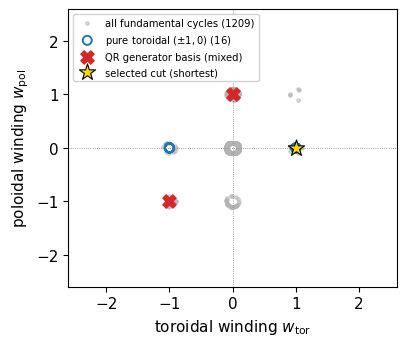

In [4]:
# --- Figure: winding-plane classification -------------------------------
plt.rcParams.update({"font.size": 11, "axes.linewidth": 0.8})
fig, ax = plt.subplots(figsize=(4.2, 3.6))
jit = W_int + 0.10*np.column_stack([np.sin(np.arange(len(W_int))),
                                    np.cos(np.arange(len(W_int)))])
ax.scatter(jit[:, 0], jit[:, 1], s=6, c="0.7", alpha=0.5,
           label=f"all fundamental cycles ({Pi.shape[0]})", zorder=1)
ax.scatter(W_int[pure_tor, 0], W_int[pure_tor, 1], s=42, facecolors="none",
           edgecolors="tab:blue", linewidths=1.4,
           label=f"pure toroidal $(\\pm1,0)$ ({len(pure_tor)})", zorder=3)
qrw = np.rint(W_sel).astype(int)
ax.scatter(qrw[:, 0], qrw[:, 1], s=90, marker="X", c="tab:red",
           label="QR generator basis (mixed)", zorder=4)
cw = np.rint(windings(cut)).astype(int)
ax.scatter([cw[0]], [cw[1]], s=150, marker="*", c="gold", edgecolors="k",
           linewidths=0.8, label="selected cut (shortest)", zorder=5)
ax.axhline(0, color="0.5", lw=0.6, ls=":"); ax.axvline(0, color="0.5", lw=0.6, ls=":")
ax.set_xlabel("toroidal winding $w_\\mathrm{tor}$")
ax.set_ylabel("poloidal winding $w_\\mathrm{pol}$")
ax.set_xlim(-2.6, 2.6); ax.set_ylim(-2.6, 2.6)
ax.set_xticks(range(-2, 3)); ax.set_yticks(range(-2, 3))
ax.legend(fontsize=7.2, loc="upper left", framealpha=0.9)
fig.tight_layout()
fig.savefig("fig_winding_classification.pdf")
plt.show()


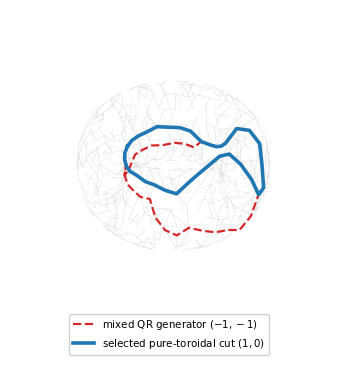

In [5]:
# --- Figure: selected cut vs a mixed QR generator, on the mesh ----------
mixed_k = int(sel[int(np.argmax([w[0] != 0 and w[1] != 0
                                 for w in np.rint(W_sel)]))])
mixed_loop = expand(mixed_k)
fig = plt.figure(figsize=(4.6, 3.8))
ax = fig.add_subplot(111, projection="3d")
Elist = list(E)
for a, c in Elist[::3]:
    ax.plot(*zip(pts[a], pts[c]), color="0.85", lw=0.3, zorder=1)
def draw(loop, **kw):
    q = pts[list(loop) + [loop[0]]]; ax.plot(q[:, 0], q[:, 1], q[:, 2], **kw)
draw(mixed_loop, color="tab:red", lw=1.6, ls="--", zorder=4,
     label="mixed QR generator $(-1,-1)$")
draw(cut, color="tab:blue", lw=2.6, zorder=5,
     label="selected pure-toroidal cut $(1,0)$")
ax.set_box_aspect((1, 1, 0.45)); ax.set_axis_off(); ax.view_init(elev=38, azim=-60)
ax.legend(fontsize=7.4, loc="upper center", bbox_to_anchor=(0.5, 0.06),
          framealpha=0.9)
fig.tight_layout()
fig.savefig("fig_cut_on_mesh.pdf")
plt.show()


In [6]:
# --- durable data sidecar (per Data Persistence Policy) -----------------
data = {
    "generated_at_utc": datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
    "radia_version": radia.__version__,
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "mesh": {"kind": "unstructured Netgen torus (revolve)",
             "R_m": R, "b_m": b, "maxh_m": maxh,
             "nv_surface": int(nv_surf), "ne": int(len(E)), "nt": int(nt),
             "chi": int(chi), "genus": int(genus),
             "mesh_nv_incl_interior": int(nv)},
    "b1": int(b1),
    "qr_generator_basis_windings": qr_basis,
    "qr_basis_is_class_mixed": bool(is_mixed),
    "n_fundamental_cycles": int(Pi.shape[0]),
    "n_pure_toroidal_candidates": int(len(pure_tor)),
    "selected_cut_winding": np.rint(windings(cut)).astype(int).tolist(),
    "selected_cut_length_mm": geo_len(cut) * 1e3,
    "selected_cut_n_vertices": int(len(cut)),
    "note": ("Unstructured torus reproduces the class-mixed QR basis "
             "recorded on the Takahashi stepped-tube workpiece; the "
             "pure-toroidal winding classification recovers the cut."),
}
with open("loop_dof_cut_selection_data.json", "w") as f:
    json.dump(data, f, indent=2)
print(json.dumps(data, indent=2))


{
  "generated_at_utc": "2026-07-22T06:02:47Z",
  "radia_version": "4.95.22",
  "python_version": "3.12.10",
  "platform": "Windows-2022Server-10.0.20348-SP0",
  "mesh": {
    "kind": "unstructured Netgen torus (revolve)",
    "R_m": 0.03,
    "b_m": 0.01,
    "maxh_m": 0.006,
    "nv_surface": 604,
    "ne": 1812,
    "nt": 1208,
    "chi": 0,
    "genus": 1,
    "mesh_nv_incl_interior": 667
  },
  "b1": 2,
  "qr_generator_basis_windings": [
    [
      -1,
      -1
    ],
    [
      0,
      1
    ]
  ],
  "qr_basis_is_class_mixed": true,
  "n_fundamental_cycles": 1209,
  "n_pure_toroidal_candidates": 16,
  "selected_cut_winding": [
    1,
    0
  ],
  "selected_cut_length_mm": 176.81253192630746,
  "selected_cut_n_vertices": 35,
  "note": "Unstructured torus reproduces the class-mixed QR basis recorded on the Takahashi stepped-tube workpiece; the pure-toroidal winding classification recovers the cut."
}
